In [7]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# train_projection_safe

以 forecast notebook 的 canonical 3-agent 配置为准。True 时重训当前 MADRL 方案；False 时严格读取当前 canonical 训练结果，并把测试 rollout 写入 `notebooks/record/madrl/`。

In [8]:

import matplotlib.pyplot as plt

from pprint import pprint

import pandas as pd
from IPython.display import display

from configs.experiment_config import MADRL_NOTEBOOK_SPECS
from configs.profiles import compose_experiment_config, project_root, summarize_experiment
from predictors.mainline_forecast import get_mainline_forecast_controls
from scripts.mainline_compare import collect_madrl_rollout, compare_rollout_metrics
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings, bootstrap_madrl_notebook_shared_data, plot_battery_power_and_soc_comparison, plot_net_load_comparison, plot_power_balance_comparison, plot_price_prediction_comparison, plot_voltage_profile_comparison, resolve_madrl_notebook_training, save_rollout_record
from scripts.utils.torch_runtime import configure_torch_runtime


In [9]:

# 唯一 notebook 参数：True 时重训当前 MADRL 方案；False 时严格读取现有 canonical run。
force_retrain_madrl = True


In [10]:

NOTEBOOK_KEY = 'train_projection_safe'
spec = MADRL_NOTEBOOK_SPECS[NOTEBOOK_KEY]
root = project_root()
cfg = compose_experiment_config(
    profile='base',
    algorithm=spec['algorithm'],
    forecast_type='lstm',
    data_dir=root / 'data',
    runtime_mode='performance',
    seed=0,
)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_notebook_experiment_settings(
    cfg,
    prediction_mode='normal',
    test_start_date=None,
    test_end_date=None,
    agent_profiles=None,
    agent_bus_ids=None,
    load_scale=None,
    pv_scale=None,
    future_horizon=int(forecast_controls['future_horizon']),
    battery_controls=None,
    forecast_controls=forecast_controls,
    train_year=None,
    test_year=None,
)
cfg.algo.name = str(spec['algorithm'])
cfg.train.num_envs = int(spec['num_envs'])
cfg.train.vec_env_type = 'subproc' if cfg.train.num_envs > 1 else 'dummy'
cfg.forecast.auto_train_missing = False
for field_name, value in dict(spec.get('reward', {})).items():
    setattr(cfg.reward, field_name, float(value))
cfg.safety.enabled = bool(dict(spec.get('safety', {})).get('enabled', False))
# 训练严格依赖 notebooks/record/forecast/lstm/shared_data_record.json 产出的 shared-data 合同。
shared_data_contract = bootstrap_madrl_notebook_shared_data(
    cfg,
    root=root,
    notebook_path='notebooks/madrl/train_projection_safe.ipynb',
)
shared_data_signature = str(shared_data_contract['shared_data_signature'])
runtime_state = configure_torch_runtime(cfg, seed=cfg.runtime.seed)
cfg.runtime.device = runtime_state.device

config_snapshot = {
    'scheme_name': str(spec['scheme_name']),
    'display_label': str(spec['display_label']),
    'algorithm': str(spec['algorithm']),
    'experiment_name': str(spec['experiment_name']),
    'force_retrain_madrl': bool(force_retrain_madrl),
    'shared_data_signature': shared_data_signature,
    'cfg_summary': summarize_experiment(cfg),
}
display(pd.DataFrame([{
    'scheme_name': spec['scheme_name'],
    'algorithm': spec['algorithm'],
    'num_envs': cfg.train.num_envs,
    'test_start_date': cfg.data.test_start_date,
    'test_end_date': cfg.data.test_end_date,
    'shared_data_signature': shared_data_signature,
}]))


,scheme_name,algorithm,num_envs,test_start_date,test_end_date,shared_data_signature
0,madrl_projection_safe,MATD3_SAFE_POC,4,2020-06-01,2020-06-07,085dfcb508e8dc62


In [11]:

# 训练编排已经统一收口到共享 helper，这里不再重复维护 payload 和旧 run 校验逻辑。



Training: 100%|██████████| 12000/12000 [13:54<00:00, 14.37step/s, avg_reward=-88.19, steps/s=57.5, act_ms=13.40, env_ms=15.09, upd_ms=41.81, eta=0.0s]


,controller,soc_mode,purchase_cost_total,purchase_cost_total_eur,export_subsidy_total,export_subsidy_total_eur,total_cost_eur,objective_total,soc_penalty_total,voltage_penalty_total,...,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur,purchase_cost_sfh12,purchase_cost_sfh18,purchase_cost_sfh20
0,MADRL + Safety Projection,reset,129.065292,129.065292,431.309814,431.309814,-302.244523,-302.212932,0.0,0.0,...,0.02266,13,102.349548,6.074421,76.53124,11.846257,NaN,36.746786,41.088643,51.229863


{'episodes_completed': 500,
 'model_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3_SAFE_POC\\normal\\train_projection_safe\\matd3_safe_poc_normal_train_projection_safe_ep500_20260423_004720',
 'record_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\notebooks\\record\\madrl\\madrl_projection_safe',
 'result_json_path': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\checkpoints\\MATD3_SAFE_POC\\normal\\train_projection_safe\\matd3_safe_poc_normal_train_projection_safe_ep500_20260423_004720\\_meta\\train_result.json',
 'shared_data_signature': '085dfcb508e8dc62'}
1. 电力电量平衡


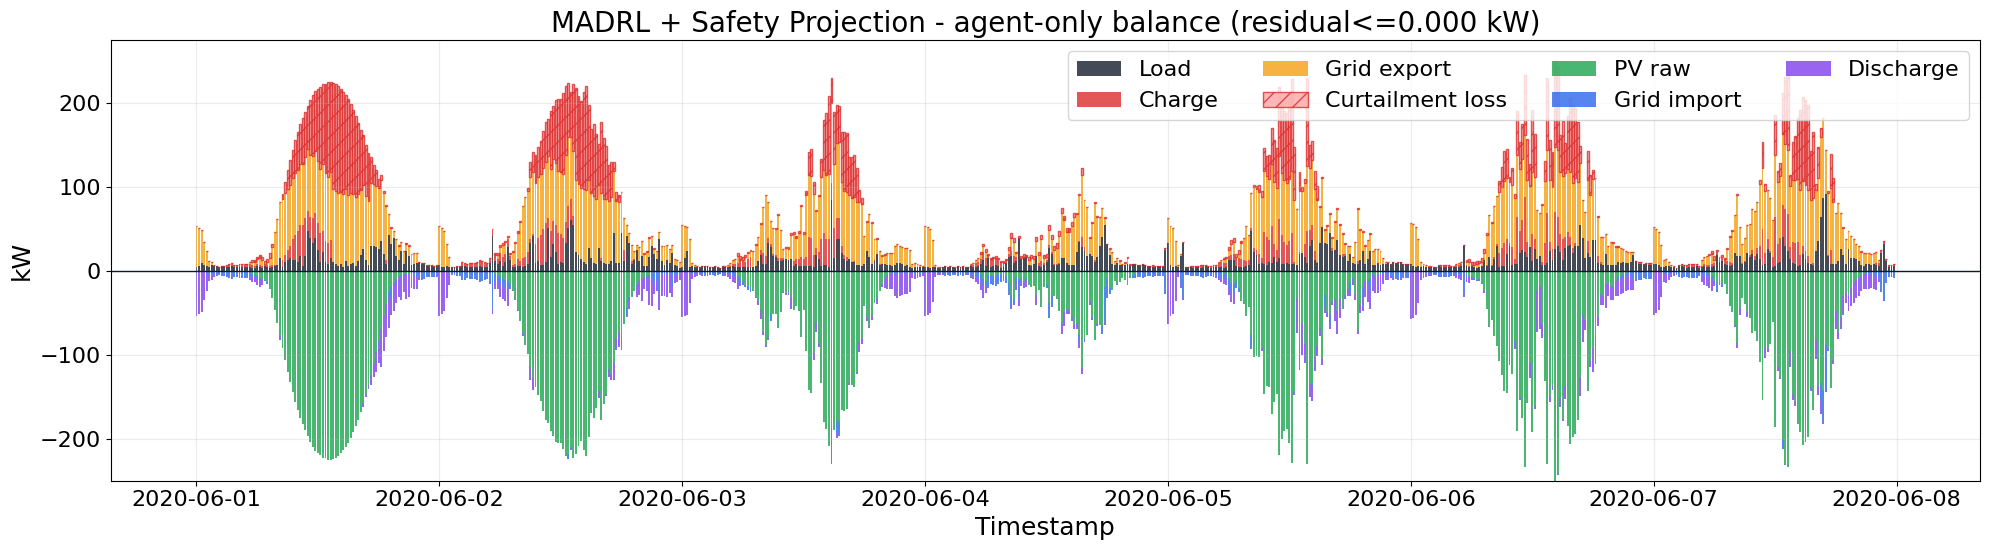

2. 电价


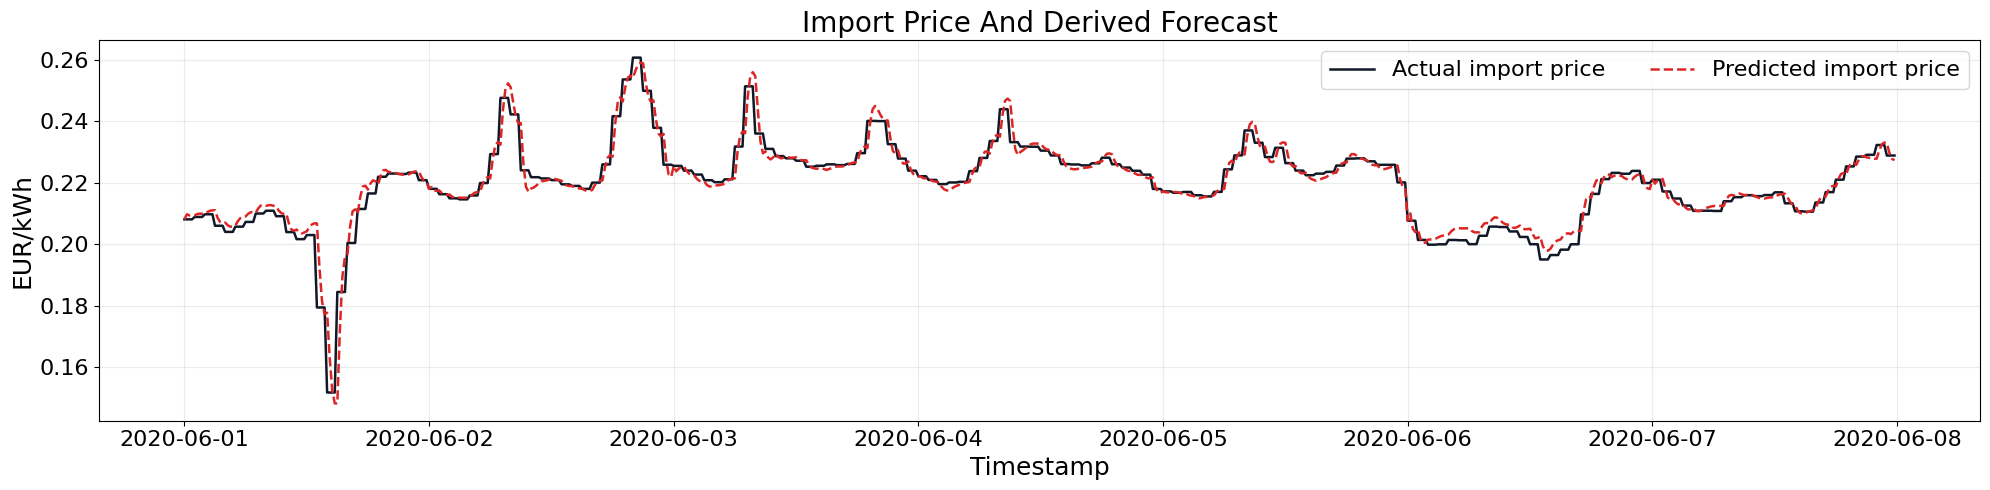

3. 总体储能充放功率与 SoC


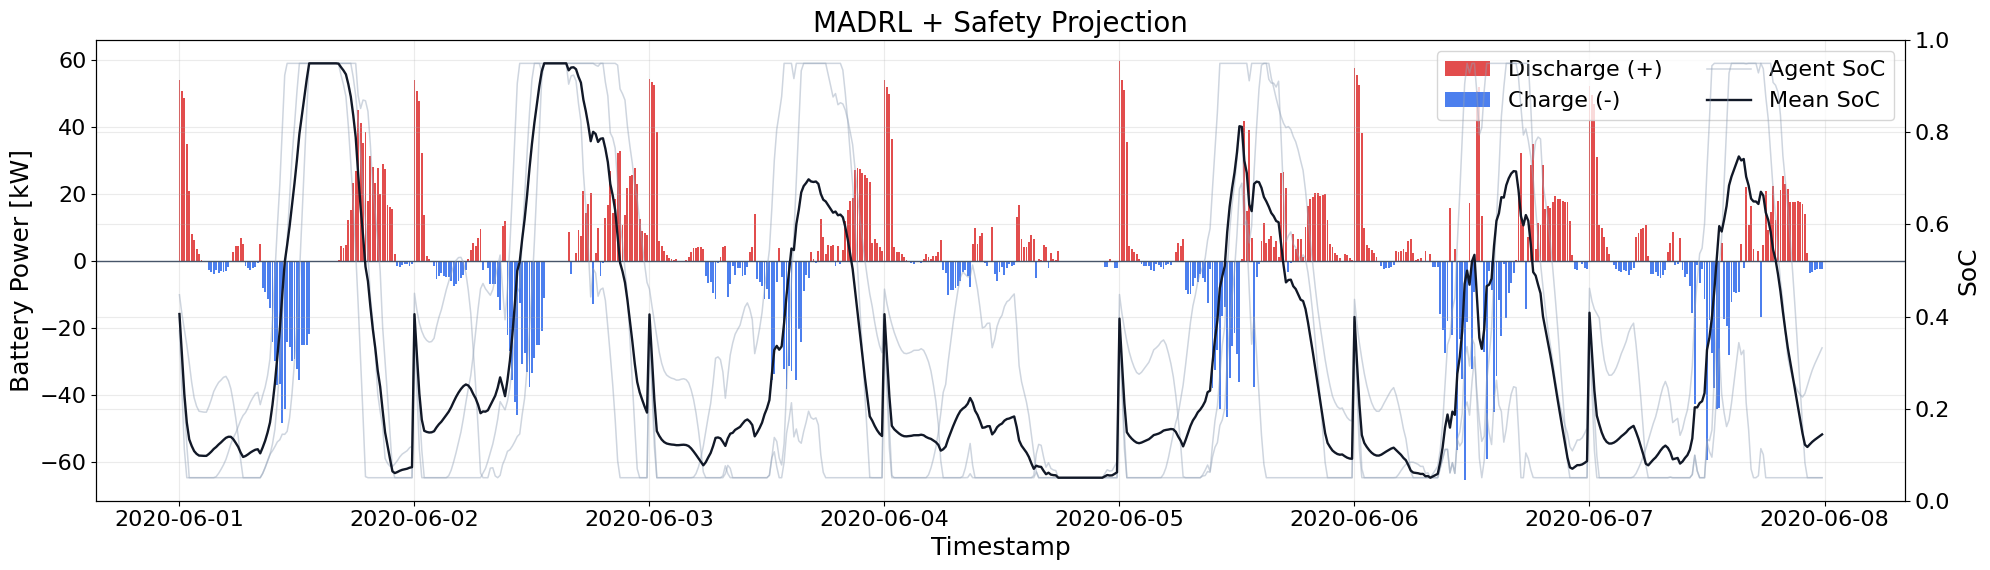

4. 电压


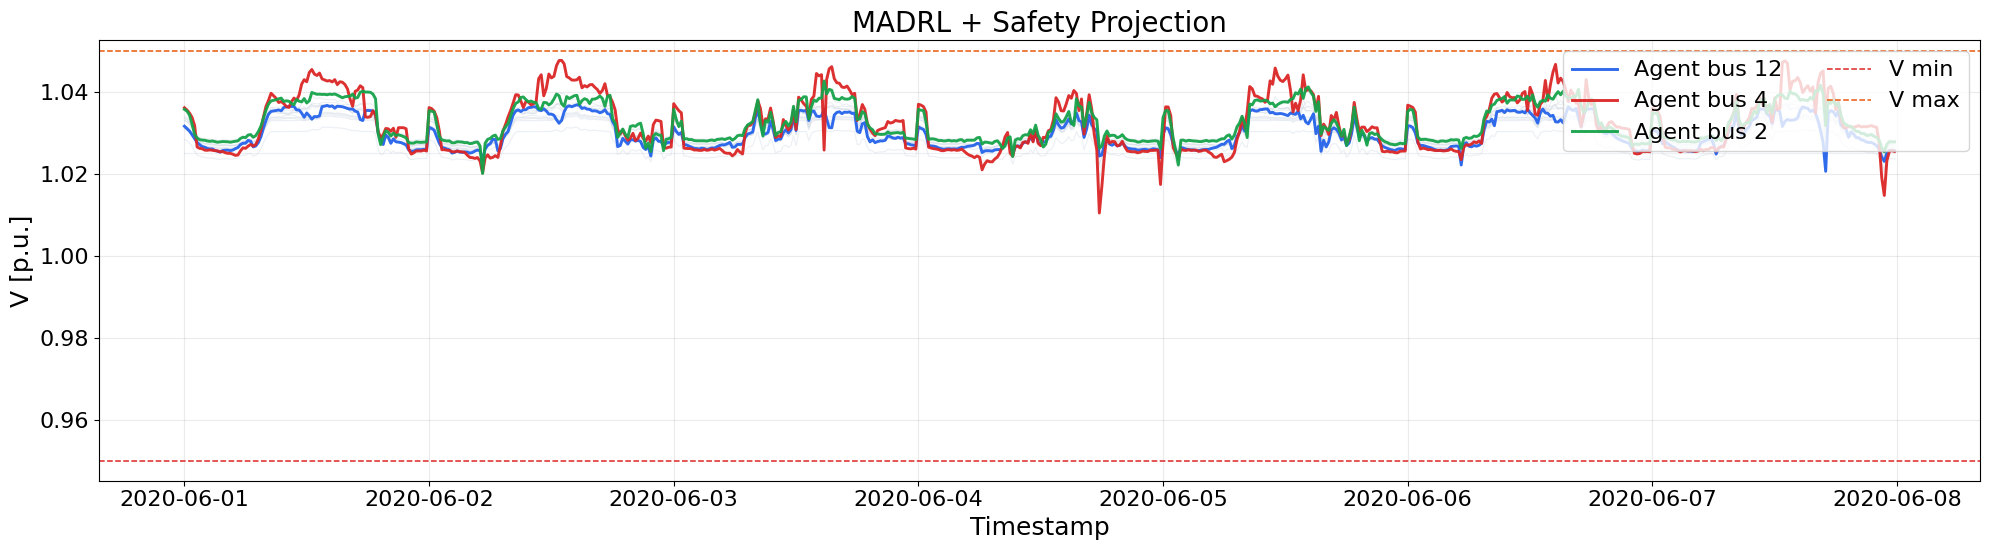

5. 净负荷


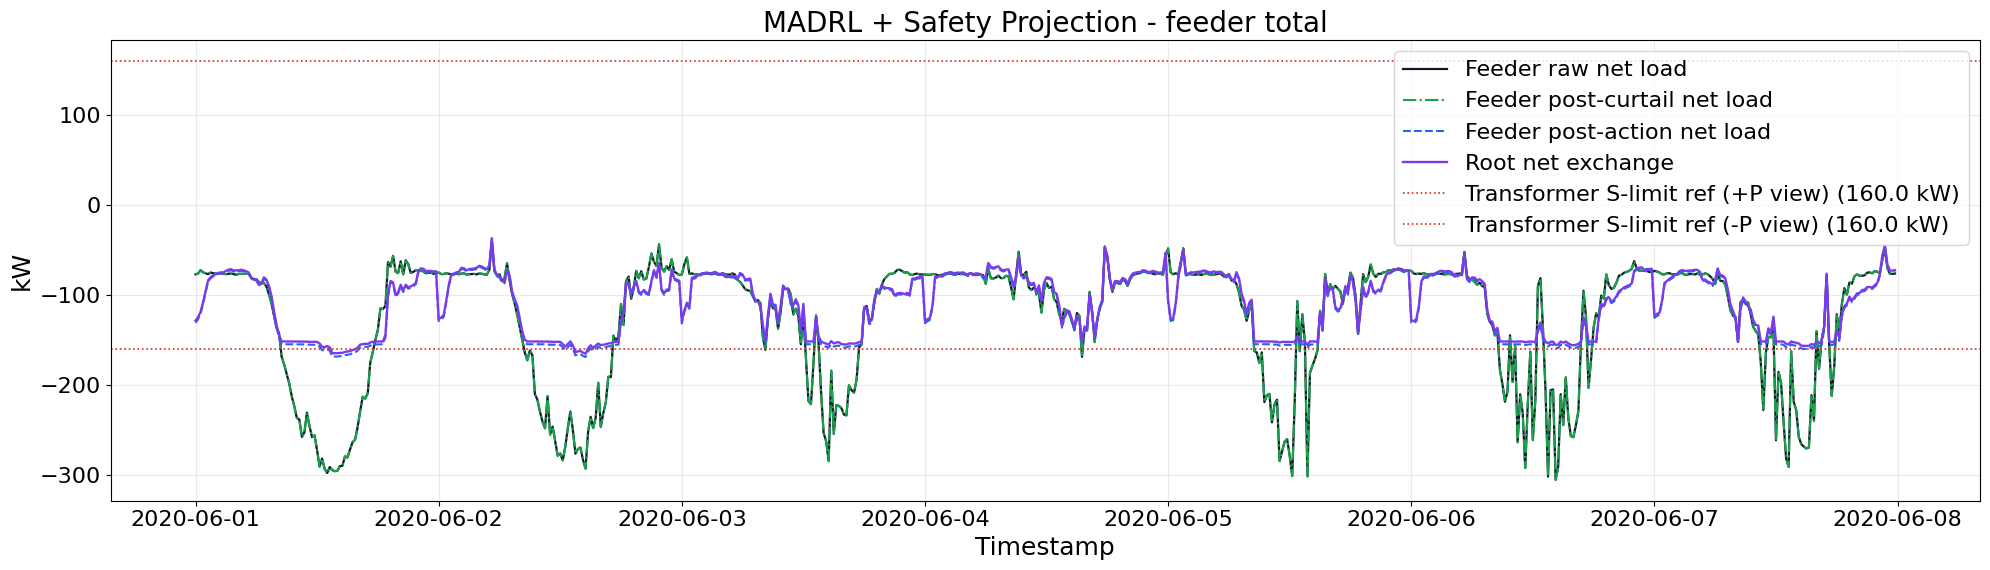

In [12]:

# 训练进度按 interaction step 推进，摘要指标每 progress_episode_interval 个 completed episodes 刷新一次。
resolved_training = resolve_madrl_notebook_training(
    cfg,
    spec=spec,
    force_retrain_madrl=bool(force_retrain_madrl),
    root=root,
    notebook_path='notebooks/madrl/train_projection_safe.ipynb',
)
train_result = dict(resolved_training['train_result'])
result_json_path = str(resolved_training['result_json_path'])
model_root = str(resolved_training['model_root'])
train_shared_data_signature = str(train_result.get('shared_data_signature') or '')

rollout = collect_madrl_rollout(
    cfg,
    model_root=model_root,
    algorithm=str(spec['algorithm']),
    experiment_name=str(spec['experiment_name']),
    label=str(spec['display_label']),
)
metrics_df = compare_rollout_metrics(rollout)
record_manifest = save_rollout_record(
    rollout,
    category='madrl',
    scheme_name=str(spec['scheme_name']),
    root=root,
    config_snapshot={
        **config_snapshot,
        'model_root': model_root,
        'result_json_path': result_json_path,
        'shared_data_signature': train_shared_data_signature,
    },
    extra_meta={
        'model_root': model_root,
        'result_json_path': result_json_path,
        'shared_data_signature': train_shared_data_signature,
    },
)
display(metrics_df)
pprint({
    'model_root': model_root,
    'result_json_path': result_json_path,
    'shared_data_signature': train_result.get('shared_data_signature'),
    'record_dir': record_manifest['record_dir'],
    'episodes_completed': int(train_result.get('episodes_completed', 0)),
})

# 统一展示 MADRL 的关键图，和 MISOCP notebook 保持同一套验收视角。
_plot_specs = [
    ('1. 电力电量平衡', plot_power_balance_comparison),
    ('2. 电价', plot_price_prediction_comparison),
    ('3. 总体储能充放功率与 SoC', plot_battery_power_and_soc_comparison),
    ('4. 电压', plot_voltage_profile_comparison),
    ('5. 净负荷', plot_net_load_comparison),
]

for title, plot_fn in _plot_specs:
    print(title)
    figure = plot_fn(rollout)
    display(figure)
    plt.close(figure)
